# Capítulo 3 — La PSF: degradación, convolución y deconvolución


En el capítulo anterior construimos el modelo de formación de imagen:

$$
g(x,y) = f(x,y) \otimes h(x,y) + n(x,y)
$$

donde:

- $f(x,y)$ es el objeto original
- $h(x,y)$ es la PSF del sistema
- $*$ representa la convolución
- $n(x,y)$ es el ruido
- $g(x,y)$ es la imagen observada

Ahora nos enfrentamos al **problema inverso**:

> Si observamos $g(x,y)$ y conocemos (o estimamos) $h(x,y)$, ¿podemos recuperar $f(x,y)$?

Ese intento de inversión recibe el nombre de **deconvolución**. Veremos que la respuesta directa es inestable,
y que necesitamos estrategias de regularización para obtener resultados útiles.

---

### Contenido del capítulo

1. Recapitulación: el modelo de degradación  
2. Por qué la deconvolución directa falla  
3. Análisis en Fourier: el problema de los ceros de la OTF  
4. Filtro de Wiener: regularización óptima  
5. Regularización de Tikhonov  
6. Método iterativo: Richardson-Lucy  
7. Comparación con métricas cuantitativas (PSNR y SSIM)  
8. Ejercicios sugeridos  
9. Conclusiones  


## 0. Importaciones

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["image.cmap"] = "gray"
np.random.seed(42)


## 1. Recapitulación: construir la imagen degradada

Partimos del mismo pipeline del Capítulo 2 para tener un caso de referencia controlado.


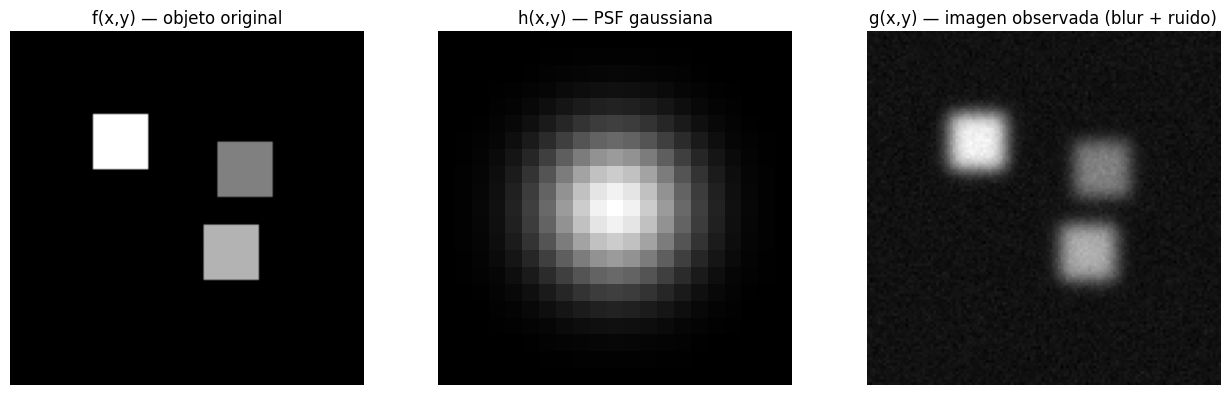

PSNR entre f y g (imagen degradada): 22.07 dB


In [3]:
# ── Objeto original ──────────────────────────────────────────────────────────
f = np.zeros((128, 128), dtype=float)
f[30:50, 30:50] = 1.0   # cuadrado grande
f[70:90, 70:90] = 0.7   # cuadrado más tenue
f[40:60, 75:95] = 0.5   # tercer cuadrado para poner a prueba la separación

# ── PSF gaussiana ────────────────────────────────────────────────────────────
def gaussian_psf(size=21, sigma=3.0):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    psf = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return psf / psf.sum()

h = gaussian_psf(size=21, sigma=3.0)

# ── Imagen borrosa ───────────────────────────────────────────────────────────
blur_limpio = convolve2d(f, h, mode="same", boundary="fill", fillvalue=0)

# ── Agregar ruido gaussiano ──────────────────────────────────────────────────
sigma_ruido = 0.02
ruido = np.random.normal(0, sigma_ruido, f.shape)
g = blur_limpio + ruido

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, img, title in zip(axes,
                           [f, h, g],
                           ["f(x,y) — objeto original",
                            "h(x,y) — PSF gaussiana",
                            "g(x,y) — imagen observada (blur + ruido)"]):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout()
plt.show()

print(f"PSNR entre f y g (imagen degradada): {psnr(f, g, data_range=1.0):.2f} dB")


## 2. Deconvolución directa (naive): por qué falla

La idea más inmediata es invertir la convolución en el dominio de Fourier.

En el dominio espacial:
$$g = f \otimes h$$

En el dominio frecuencial:
$$G = F \cdot H \implies F = \frac{G}{H}$$

Esto se llama **filtro inverso** o deconvolución directa. Parece razonable. El problema es que:

- $H$ puede tener valores **muy cercanos a cero** (o exactamente cero) en ciertas frecuencias.
- Dividir por un número pequeño **amplifica enormemente** el ruido en esas frecuencias.
- El resultado es una imagen dominada por artefactos de alta frecuencia.

Veamos esto en acción.


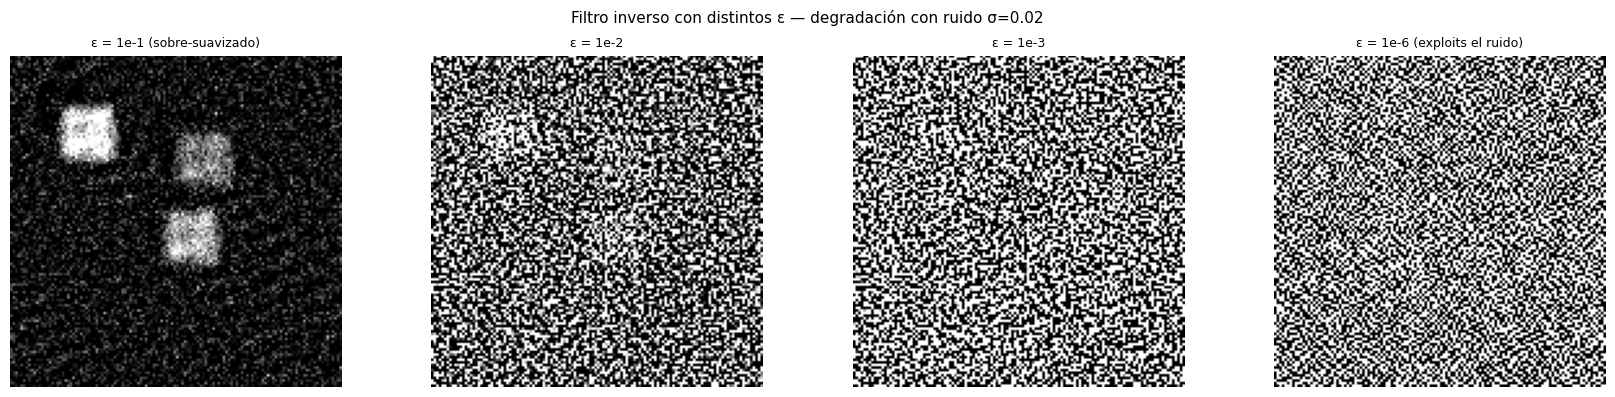

In [4]:
def filtro_inverso(g, h, epsilon=1e-3):
    """Deconvolución directa con regularización mínima (naive)."""
    G = np.fft.fft2(g)
    H = np.fft.fft2(h, s=g.shape)
    F_est = G / (H + epsilon)
    return np.real(np.fft.ifft2(F_est))

# Probar con distintos valores de epsilon
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, eps, title in zip(
    axes,
    [1e-1, 1e-2, 1e-3, 1e-6],
    ["ε = 1e-1 (sobre-suavizado)", "ε = 1e-2", "ε = 1e-3", "ε = 1e-6 (exploits el ruido)"]
):
    rec = filtro_inverso(g, h, epsilon=eps)
    ax.imshow(rec, vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle("Filtro inverso con distintos ε — degradación con ruido σ=0.02", fontsize=11)
plt.tight_layout()
plt.show()


### Interpretación

- Con **ε grande** el filtro inverso se comporta como un suavizador: pierde detalle pero no explota.
- Con **ε pequeño** el filtro intenta recuperar todas las frecuencias, incluidas aquellas donde H ≈ 0,
  y el ruido es amplificado catastróficamente.

Ningún valor de ε resuelve el problema de fondo: la deconvolución directa no tiene mecanismo
para distinguir señal de ruido. Para eso necesitamos **regularización**.


## 3. Análisis en Fourier: el problema de los ceros de la OTF

La Función de Transferencia Óptica (**OTF**, Optical Transfer Function) es la transformada de Fourier
de la PSF:

$$H(f_x, f_y) = \mathcal{F}\{h(x,y)\}$$

Su módulo se llama **MTF** (Modulation Transfer Function) y describe cómo el sistema atenúa
cada frecuencia espacial.

Una PSF gaussiana atenúa las altas frecuencias de forma progresiva. Esto es fundamental
para entender por qué la deconvolución directa falla: hay regiones del espectro donde $|H|$
es prácticamente cero, y allí la división amplifica el ruido de forma ilimitada.


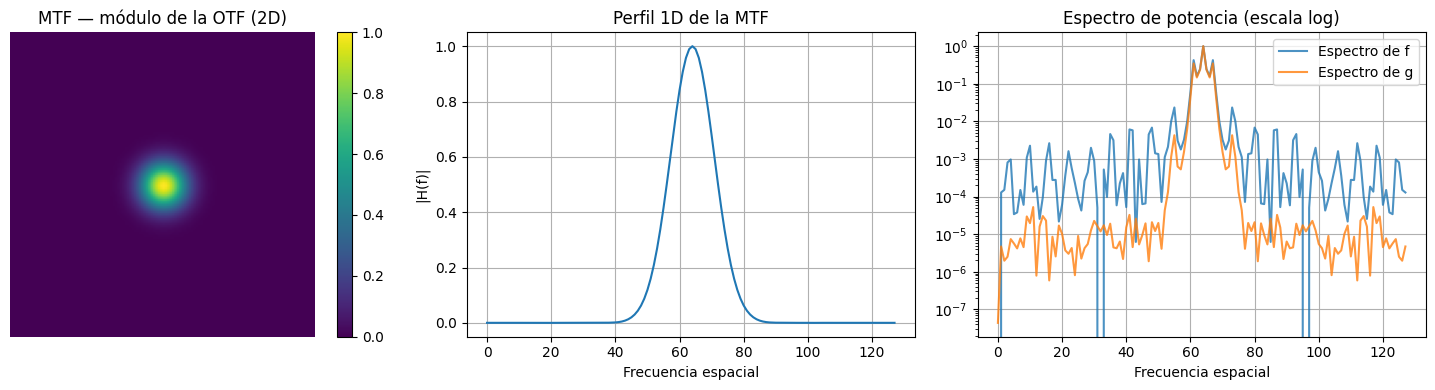

In [5]:
H = np.fft.fftshift(np.fft.fft2(h, s=f.shape))
MTF = np.abs(H)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MTF 2D
im = axes[0].imshow(MTF, cmap="viridis")
axes[0].set_title("MTF — módulo de la OTF (2D)")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0])

# Perfil 1D central de la MTF
perfil_mtf = MTF[MTF.shape[0] // 2, :]
axes[1].plot(perfil_mtf)
axes[1].set_title("Perfil 1D de la MTF")
axes[1].set_xlabel("Frecuencia espacial")
axes[1].set_ylabel("|H(f)|")
axes[1].grid(True)

# Espectro de potencia de f y de g
Sf = np.abs(np.fft.fftshift(np.fft.fft2(f)))**2
Sg = np.abs(np.fft.fftshift(np.fft.fft2(g)))**2
perfil_f = Sf[Sf.shape[0] // 2, :]
perfil_g = Sg[Sg.shape[0] // 2, :]
axes[2].semilogy(perfil_f / perfil_f.max(), label="Espectro de f", alpha=0.8)
axes[2].semilogy(perfil_g / perfil_g.max(), label="Espectro de g", alpha=0.8)
axes[2].set_title("Espectro de potencia (escala log)")
axes[2].set_xlabel("Frecuencia espacial")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


### Qué vemos

- La MTF de la PSF gaussiana cae suavemente hacia las altas frecuencias.
- El espectro de $g$ (imagen degradada) pierde potencia en altas frecuencias respecto a $f$.
- En esas zonas donde $|H| \approx 0$, el ruido domina completamente la relación señal/ruido.
- Recuperar esas frecuencias sin información adicional es matemáticamente imposible sin asumir algo.

Esa asunción adicional es la **regularización**.


## 4. Filtro de Wiener

El filtro de Wiener es la solución óptima en el sentido del error cuadrático medio,
asumiendo que las estadísticas del objeto y del ruido son conocidas.

La fórmula en el dominio de Fourier es:

$$\hat{F}(f_x,f_y) = \frac{H^*(f_x,f_y)}{|H(f_x,f_y)|^2 + K} \cdot G(f_x,f_y)$$

donde:
- $H^*$ es el conjugado complejo de la OTF
- $K = S_n / S_f$ es la relación entre el espectro de potencia del ruido y el de la señal
- Cuando el ruido es bajo ($K \to 0$), se aproxima al filtro inverso ideal
- Cuando el ruido es alto ($K$ grande), el filtro suaviza y evita amplificar el ruido

El parámetro $K$ actúa como **regularizador**: equilibra la fidelidad a la observación
con la penalización de las soluciones ruidosas.


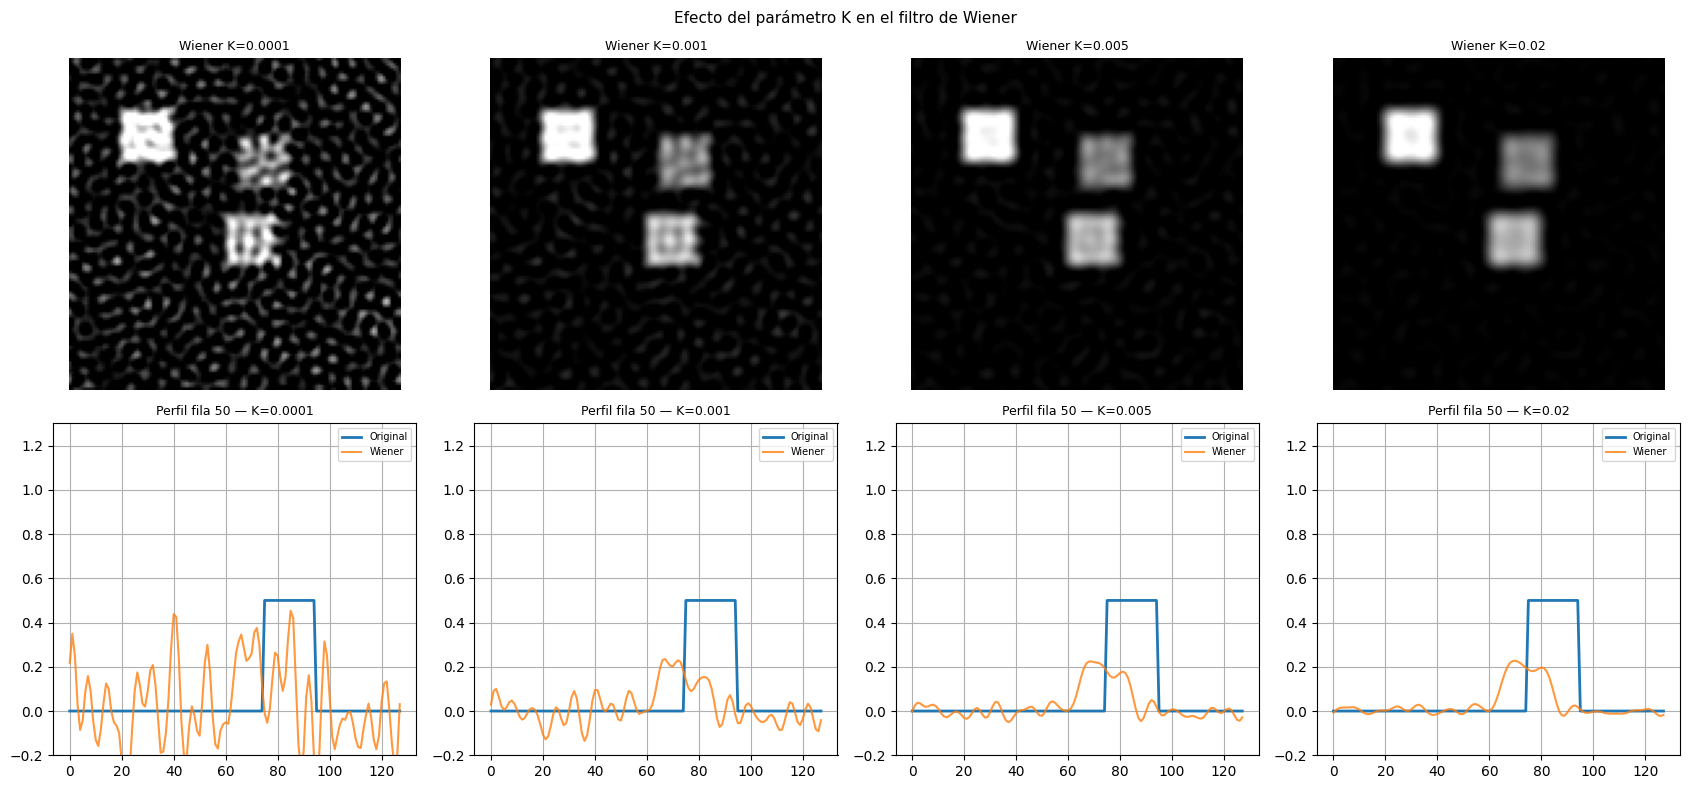

In [6]:
def filtro_wiener(g, h, K=0.01):
    """
    Filtro de Wiener.
    K ≈ SNR_ruido / SNR_señal. Valores típicos: 0.001 – 0.1.
    """
    G = np.fft.fft2(g)
    H = np.fft.fft2(h, s=g.shape)
    H_conj = np.conj(H)
    W = H_conj / (np.abs(H)**2 + K)
    F_est = W * G
    return np.real(np.fft.ifft2(F_est))

# Explorar varios valores de K
fig, axes = plt.subplots(2, 4, figsize=(17, 8))

Ks = [1e-4, 1e-3, 5e-3, 2e-2]
for col, K in enumerate(Ks):
    rec = filtro_wiener(g, h, K=K)
    axes[0, col].imshow(rec, vmin=0, vmax=1)
    axes[0, col].set_title(f"Wiener K={K}", fontsize=9)
    axes[0, col].axis("off")

    # Perfil de comparación
    fila = rec[50, :]
    axes[1, col].plot(f[50, :], label="Original", linewidth=2)
    axes[1, col].plot(fila, label="Wiener", alpha=0.8)
    axes[1, col].set_ylim(-0.2, 1.3)
    axes[1, col].legend(fontsize=7)
    axes[1, col].grid(True)
    axes[1, col].set_title(f"Perfil fila 50 — K={K}", fontsize=9)

plt.suptitle("Efecto del parámetro K en el filtro de Wiener", fontsize=11)
plt.tight_layout()
plt.show()


In [7]:
# Métricas para cada K
print(f"{'K':>10}  {'PSNR (dB)':>10}  {'SSIM':>8}")
print("-" * 32)
for K in [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]:
    rec = filtro_wiener(g, h, K=K)
    rec_clip = np.clip(rec, 0, 1)
    p = psnr(f, rec_clip, data_range=1.0)
    s = ssim(f, rec_clip, data_range=1.0)
    print(f"{K:>10.0e}  {p:>10.2f}  {s:>8.4f}")


         K   PSNR (dB)      SSIM
--------------------------------
     1e-04       11.49   -0.0005
     5e-04       12.19    0.0347
     1e-03       12.29    0.0829
     5e-03       12.41    0.3285
     1e-02       12.46    0.4550
     5e-02       12.67    0.6538


## 5. Regularización de Tikhonov

El filtro de Wiener asume estadísticas estacionarias de señal y ruido.
Una alternativa más general es la regularización de **Tikhonov**, que penaliza
soluciones con gradiente elevado (soluciones rugosas).

La solución en frecuencia es:

$$\hat{F} = \frac{H^*}{|H|^2 + \lambda \, |L|^2} \cdot G$$

donde $L$ es un operador de regularización. El caso más simple es $L = I$ (identidad),
que equivale a penalizar la energía de la solución, equivalente al filtro de Wiener con $K=\lambda$.

Una versión más sofisticada usa el **operador laplaciano** como $L$, lo que penaliza
las variaciones bruscas de segundo orden y tiende a producir reconstrucciones más suaves.


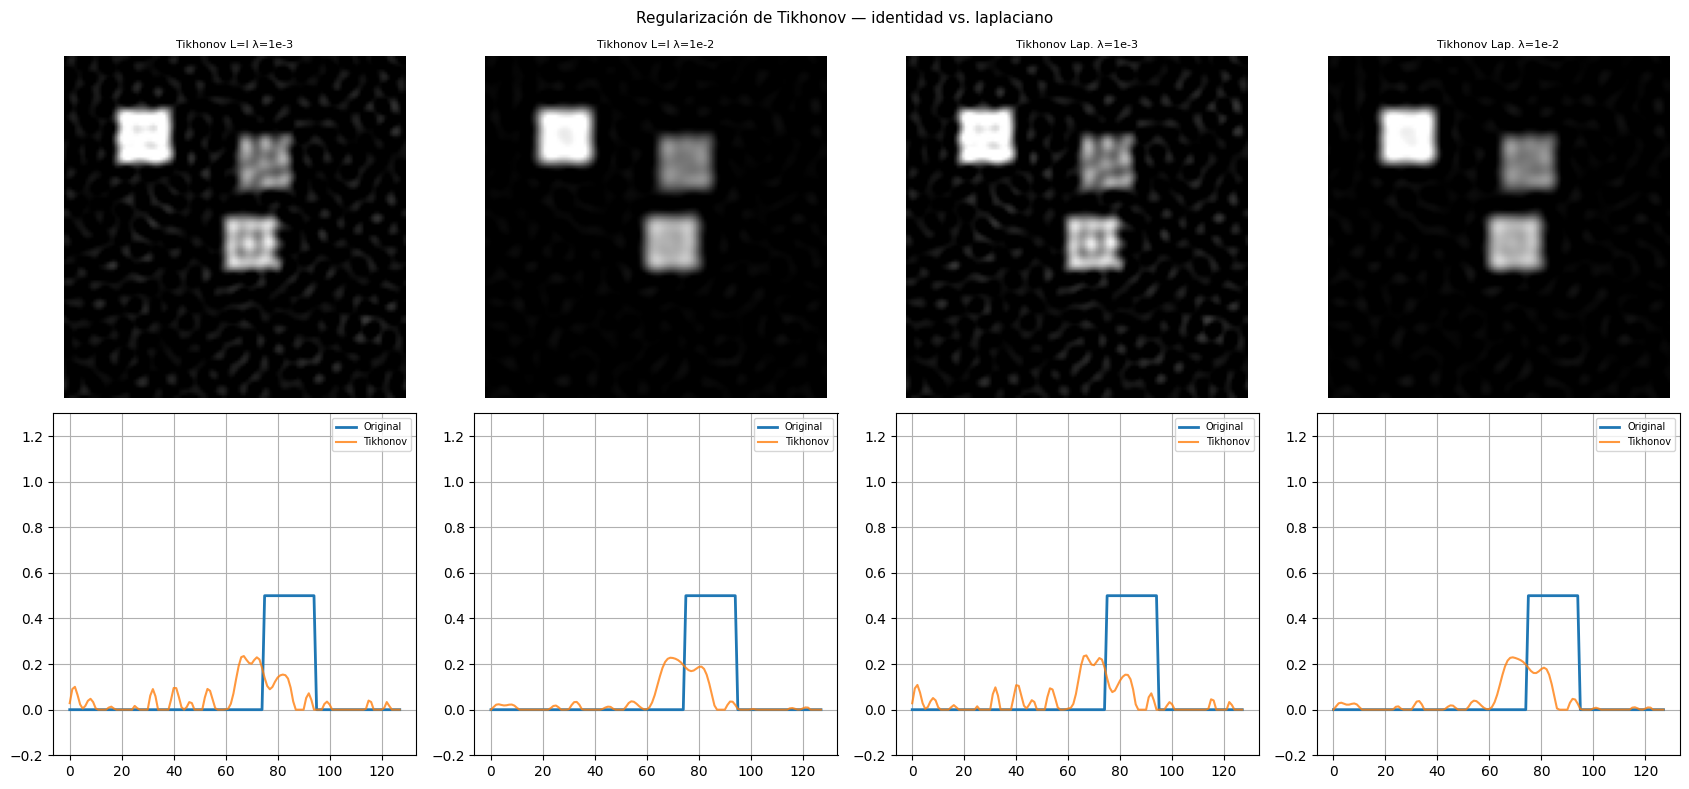

In [8]:
def tikhonov(g, h, lam=0.01, usar_laplaciano=False):
    """
    Regularización de Tikhonov.
    usar_laplaciano=True penaliza el gradiente (suavidad de segundo orden).
    """
    G = np.fft.fft2(g)
    H = np.fft.fft2(h, s=g.shape)

    if usar_laplaciano:
        # Operador laplaciano en frecuencia
        fy = np.fft.fftfreq(g.shape[0])
        fx = np.fft.fftfreq(g.shape[1])
        FX, FY = np.meshgrid(fx, fy)
        L2 = (2 * np.pi)**2 * (FX**2 + FY**2)
    else:
        L2 = 1.0

    W = np.conj(H) / (np.abs(H)**2 + lam * L2)
    return np.real(np.fft.ifft2(W * G))

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
configs = [
    (1e-3, False, "Tikhonov L=I λ=1e-3"),
    (1e-2, False, "Tikhonov L=I λ=1e-2"),
    (1e-3, True,  "Tikhonov Lap. λ=1e-3"),
    (1e-2, True,  "Tikhonov Lap. λ=1e-2"),
]
for col, (lam, lap, title) in enumerate(configs):
    rec = tikhonov(g, h, lam=lam, usar_laplaciano=lap)
    axes[0, col].imshow(np.clip(rec, 0, 1), vmin=0, vmax=1)
    axes[0, col].set_title(title, fontsize=8)
    axes[0, col].axis("off")
    axes[1, col].plot(f[50, :], label="Original", linewidth=2)
    axes[1, col].plot(np.clip(rec[50, :], 0, 1), label="Tikhonov", alpha=0.8)
    axes[1, col].set_ylim(-0.2, 1.3)
    axes[1, col].legend(fontsize=7)
    axes[1, col].grid(True)

plt.suptitle("Regularización de Tikhonov — identidad vs. laplaciano", fontsize=11)
plt.tight_layout()
plt.show()


## 6. Método iterativo: Richardson-Lucy

Los métodos anteriores son soluciones de forma cerrada en frecuencia.
Richardson-Lucy (RL) es un algoritmo iterativo que toma un enfoque diferente:
asume que el ruido sigue una distribución de **Poisson** (natural en sistemas de conteo
de fotones, como microscopía o astronomía) y maximiza la verosimilitud.

La regla de actualización en cada iteración es:

$$f^{(k+1)} = f^{(k)} \cdot \left( h^T \otimes \frac{g}{h \otimes f^{(k)}} \right)$$

donde $h^T$ es la PSF volteada (adjunta).

Propiedades clave:
- Preserva la positividad de la solución (nunca produce valores negativos)
- Converge en pocas iteraciones para imágenes poco ruidosas
- Con demasiadas iteraciones amplifica el ruido (requiere parada temprana)


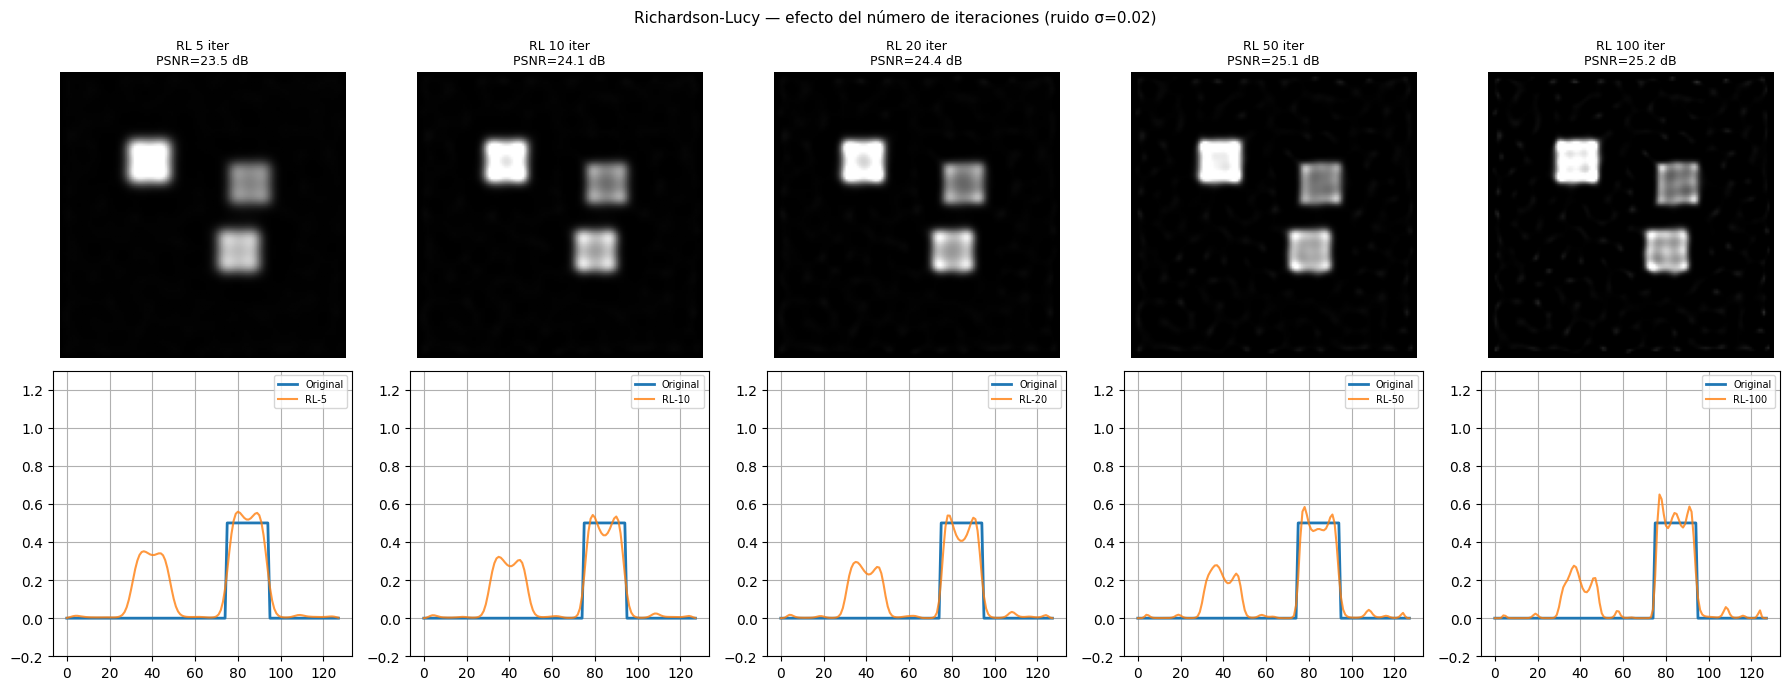

In [9]:
def richardson_lucy(g, h, n_iter=30, clip_min=1e-6):
    """
    Algoritmo de Richardson-Lucy.
    g : imagen observada (debe ser no-negativa)
    h : PSF normalizada
    n_iter : número de iteraciones
    """
    h_flip = np.flip(h)
    # Inicialización: imagen uniforme con la media de g
    f_est = np.full_like(g, g.mean())
    g_pos = np.maximum(g, clip_min)

    for _ in range(n_iter):
        conv = convolve2d(f_est, h, mode="same", boundary="fill", fillvalue=0)
        ratio = g_pos / np.maximum(conv, clip_min)
        correction = convolve2d(ratio, h_flip, mode="same", boundary="fill", fillvalue=0)
        f_est = f_est * correction

    return f_est

# Efecto del número de iteraciones
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
iters = [5, 10, 20, 50, 100]

g_pos = np.maximum(g, 0)  # RL requiere datos no-negativos

for col, n in enumerate(iters):
    rec = richardson_lucy(g_pos, h, n_iter=n)
    rec_clip = np.clip(rec, 0, 1)
    p = psnr(f, rec_clip, data_range=1.0)
    s = ssim(f, rec_clip, data_range=1.0)

    axes[0, col].imshow(rec_clip, vmin=0, vmax=1)
    axes[0, col].set_title(f"RL {n} iter\nPSNR={p:.1f} dB", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].plot(f[50, :], label="Original", linewidth=2)
    axes[1, col].plot(rec_clip[50, :], label=f"RL-{n}", alpha=0.8)
    axes[1, col].set_ylim(-0.2, 1.3)
    axes[1, col].legend(fontsize=7)
    axes[1, col].grid(True)

plt.suptitle("Richardson-Lucy — efecto del número de iteraciones (ruido σ=0.02)", fontsize=11)
plt.tight_layout()
plt.show()


### Curva PSNR vs. iteraciones

Podemos graficar cómo evoluciona la calidad de la reconstrucción a medida que iteramos.
Habrá un máximo: antes de ese punto la imagen mejora; después, el ruido comienza a dominar.


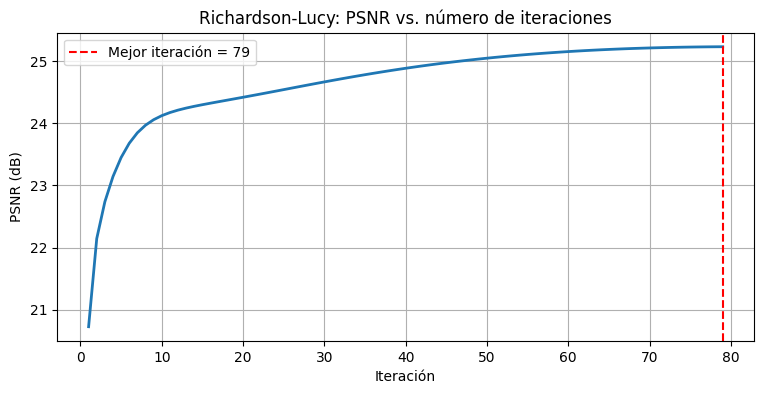

Mejor PSNR: 25.24 dB en la iteración 79


In [10]:
psnr_vals = []
iters_range = list(range(1, 80))

g_pos = np.maximum(g, 0)
f_est = np.full_like(g_pos, g_pos.mean())
h_flip = np.flip(h)

for i in iters_range:
    conv = convolve2d(f_est, h, mode="same", boundary="fill", fillvalue=0)
    ratio = g_pos / np.maximum(conv, 1e-6)
    correction = convolve2d(ratio, h_flip, mode="same", boundary="fill", fillvalue=0)
    f_est = f_est * correction
    psnr_vals.append(psnr(f, np.clip(f_est, 0, 1), data_range=1.0))

mejor_iter = iters_range[np.argmax(psnr_vals)]

plt.figure(figsize=(9, 4))
plt.plot(iters_range, psnr_vals, linewidth=2)
plt.axvline(mejor_iter, color="red", linestyle="--", label=f"Mejor iteración = {mejor_iter}")
plt.xlabel("Iteración")
plt.ylabel("PSNR (dB)")
plt.title("Richardson-Lucy: PSNR vs. número de iteraciones")
plt.legend()
plt.grid(True)
plt.show()

print(f"Mejor PSNR: {max(psnr_vals):.2f} dB en la iteración {mejor_iter}")


## 7. Comparación global con métricas cuantitativas

### PSNR (Peak Signal-to-Noise Ratio)

$$\text{PSNR} = 10 \log_{10}\!\left(\frac{\text{MAX}^2}{\text{MSE}}\right)$$

Cuanto mayor, mejor. Por encima de 30 dB se considera buena calidad; por encima de 40 dB, excelente.

### SSIM (Structural Similarity Index)

Mide similitud estructural entre imagen original y reconstruida.
Varía entre -1 y 1; valores cercanos a 1 indican alta similaridad percibida.


In [11]:
# Parámetros óptimos aproximados para este ejemplo
rec_inverso  = np.clip(filtro_inverso(g, h, epsilon=1e-2), 0, 1)
rec_wiener   = np.clip(filtro_wiener(g, h, K=1e-3), 0, 1)
rec_tikhonov = np.clip(tikhonov(g, h, lam=5e-3, usar_laplaciano=True), 0, 1)
rec_rl       = np.clip(richardson_lucy(np.maximum(g, 0), h, n_iter=mejor_iter), 0, 1)

metodos = {
    "Imagen degradada g": np.clip(g, 0, 1),
    "Filtro inverso":     rec_inverso,
    "Wiener":             rec_wiener,
    "Tikhonov-Lap.":      rec_tikhonov,
    "Richardson-Lucy":    rec_rl,
}

print(f"{'Método':<22}  {'PSNR (dB)':>10}  {'SSIM':>8}")
print("-" * 44)
for nombre, rec in metodos.items():
    p = psnr(f, rec, data_range=1.0)
    s = ssim(f, rec, data_range=1.0)
    print(f"{nombre:<22}  {p:>10.2f}  {s:>8.4f}")


Método                   PSNR (dB)      SSIM
--------------------------------------------
Imagen degradada g           22.19    0.4783
Filtro inverso                4.27   -0.0002
Wiener                       12.29    0.0829
Tikhonov-Lap.                12.37    0.2650
Richardson-Lucy              25.24    0.5677


In [ ]:
# Panel visual de comparación
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

imagenes = [("f — Original", f)] + list(metodos.items())
for ax, (title, img) in zip(axes, imagenes):
    p = psnr(f, np.clip(img, 0, 1), data_range=1.0) if title != "f — Original" else float('inf')
    s = ssim(f, np.clip(img, 0, 1), data_range=1.0) if title != "f — Original" else 1.0
    label = f"{title}\nPSNR={p:.1f} dB  SSIM={s:.3f}" if title != "f — Original" else title
    ax.imshow(np.clip(img, 0, 1), vmin=0, vmax=1)
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.suptitle("Comparación de métodos de deconvolución", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# Perfiles horizontales comparativos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fila = 50
colores = ["gray", "orange", "blue", "green", "red"]
for ax_idx in range(2):
    ax = axes[ax_idx]
    ax.plot(f[fila, :], "k-", linewidth=2.5, label="Original")
    for (nombre, rec), color in zip(list(metodos.items())[ax_idx*2:(ax_idx+1)*2+1], colores):
        ax.plot(np.clip(rec[fila, :], 0, 1), label=nombre, alpha=0.85, color=color)
    ax.set_ylim(-0.2, 1.3)
    ax.set_xlabel("Posición en x")
    ax.set_ylabel("Intensidad")
    ax.set_title(f"Perfil fila {fila}")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle("Perfiles de intensidad — comparación de métodos", fontsize=11)
plt.tight_layout()
plt.show()


## 8. Ejercicios sugeridos

1. **Efecto del nivel de ruido**: cambia `sigma_ruido` a 0.005, 0.05 y 0.1.
   ¿Cómo afecta al método óptimo y a los parámetros de regularización?

2. **PSF más ancha**: usa `sigma=6` en la PSF gaussiana. ¿Cuál método degrada más su rendimiento?

3. **PSF de movimiento**: implementa una PSF de motion blur (una línea horizontal de 1s normalizada)
   y compara los resultados con la PSF gaussiana.

4. **Estimación automática de K en Wiener**: calcula $K = \sigma_n^2 / \sigma_f^2$ a partir de los datos
   y compara con el K que maximiza el PSNR por búsqueda exhaustiva.

5. **Richardson-Lucy con parada temprana**: en lugar de iterar hasta el mejor PSNR (trampa),
   implementa un criterio de parada basado en la variación relativa entre iteraciones consecutivas.

6. **Deconvolución ciega (blind)**: en todos los experimentos anteriores asumimos que conocemos $h$.
   ¿Qué ocurre si pasas una PSF incorrecta (sigma=2 en lugar de sigma=3) a cada método?


## 9. Conclusiones

En este capítulo abordamos el **problema inverso** de la formación de imagen:

| Método | Principio | Ventaja | Limitación |
|---|---|---|---|
| **Filtro inverso** | División directa en Fourier | Sencillo, instantáneo | Amplifica ruido en altas frecuencias |
| **Filtro de Wiener** | Minimización del MSE | Óptimo estadísticamente, un parámetro | Asume estadísticas estacionarias |
| **Tikhonov** | Penalización de rugosidad | Flexible, laplaciano controla suavidad | Puede sobresuavizar bordes |
| **Richardson-Lucy** | Verosimilitud Poisson, iterativo | Preserva positividad, muy bueno con fotones | Converge al ruido sin parada temprana |

### Ideas clave

- La deconvolución directa es inestable porque la OTF tiene valores muy pequeños o cero.
- La regularización añade una asunción *a priori* sobre la solución que estabiliza el problema.
- El parámetro de regularización controla el equilibrio entre fidelidad y suavidad.
- Las métricas PSNR y SSIM permiten comparar reconstrucciones de forma objetiva.
- El mejor método depende del tipo de ruido, del nivel de ruido y del conocimiento previo sobre la imagen.

---

## Próximo notebook

**Capítulo 4 — Redes convolucionales para imaging (CNNs)**

Veremos cómo las CNNs pueden aprender implícitamente a deconvolucionar imágenes,
superando a los métodos clásicos cuando se dispone de datos de entrenamiento suficientes.
